In [1]:
def pizza_price_model(size):
    weight = 2  
    bias = 3    
    price = weight * size + bias  
    return price

size = 5  
predicted_price = pizza_price_model(size)
print(f"{size}인치 피자 예상 가격: {predicted_price}천원")

5인치 피자 예상 가격: 13천원


In [2]:
import torch

def forward_pass(x, W, b):

    z = torch.mm(x, W) + b
    output = torch.relu(z)
    return output

x = torch.tensor([[1.0, 2.0],
                  [3.0, 4.0]])

W = torch.tensor([[0.5, -0.5],
                  [1.0,  1.0]])

b = torch.tensor([[1.0, 1.0]])

output = forward_pass(x, W, b)
print(output)

tensor([[3.5000, 2.5000],
        [6.5000, 3.5000]])


In [3]:
import torch
import torch.nn as nn

x = torch.tensor([[1.0], [2.0], [3.0], [4.0]])
y_true = 2 * x + 1

model_output = torch.tensor([[2.5], [3.5], [4.5], [5.5]])

criterion = nn.MSELoss()

loss = criterion(model_output, y_true)
print(loss)

tensor(5.2500)


In [4]:
actual_price = 11
predicted_price = 13
error = predicted_price - actual_price  

print(error)

weight = 2
bias = 3

learning_rate = 0.01
weight = weight - learning_rate * error * size  
bias = bias - learning_rate * error             

print(weight, bias)

2
1.9 2.98


In [5]:

# Input
x = torch.tensor(2.0, requires_grad=True)

# Forward
y = x**2 + 3*x + 4

# Backward
y.backward()

print(x.grad) 

tensor(7.)


In [6]:
x = torch.tensor([[1.0, 2.0], [3.0, 4.0]], requires_grad=True)

y = (x ** 2).sum()

y.backward()

print(x.grad)

tensor([[2., 4.],
        [6., 8.]])


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim

class LinearRegressionModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(LinearRegressionModel, self).__init__()
        self.linear = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        return self.linear(x)

x = torch.tensor([[1.0], [2.0], [3.0], [4.0]])
y_true = 2 * x + 1

model = LinearRegressionModel(1, 1)
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

for epoch in range(100):
    optimizer.zero_grad()               
    # 순전파
    pred = model(x)                     
    # 로스계산
    loss = criterion(pred, y_true)     
    # 역전파 
    loss.backward()                
    # 적용된 파라미터 적용     
    optimizer.step()                    

    if (epoch + 1) % 20 == 0:
        print(epoch+1, loss.item())


20 0.12344580143690109
40 0.056980032473802567
60 0.05050477385520935
80 0.04479661211371422
100 0.03973351791501045


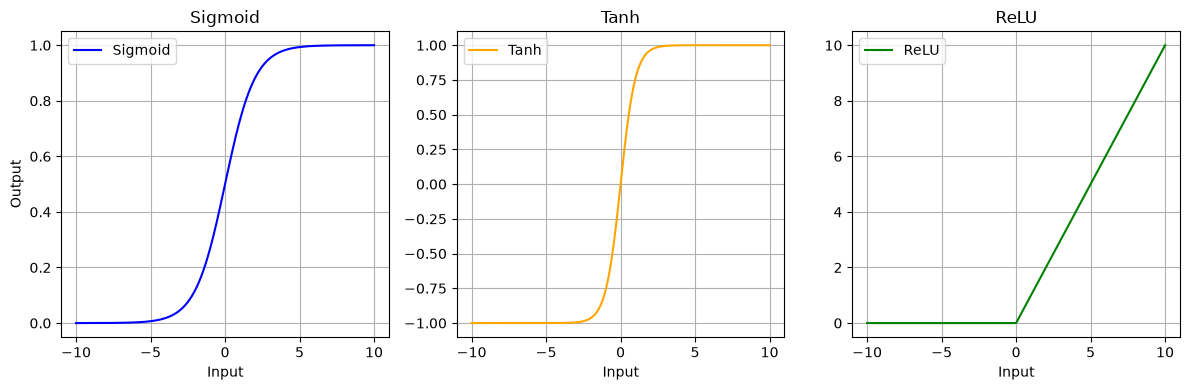

In [8]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 400)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def relu(x):
    return np.maximum(0, x)

y_sigmoid = sigmoid(x)
y_tanh = tanh(x)
y_relu = relu(x)

# 하나의 Figure 안에 3개의 Subplot(1행 3열)을 생성
plt.figure(figsize=(12, 4))

# 1) Sigmoid
plt.subplot(1, 3, 1)
plt.plot(x, y_sigmoid, label='Sigmoid', color='blue')
plt.xlabel('Input')
plt.ylabel('Output')
plt.title('Sigmoid')
plt.grid(True)
plt.legend()

# 2) Tanh
plt.subplot(1, 3, 2)
plt.plot(x, y_tanh, label='Tanh', color='orange')
plt.xlabel('Input')
plt.title('Tanh')
plt.grid(True)
plt.legend()

# 3) ReLU
plt.subplot(1, 3, 3)
plt.plot(x, y_relu, label='ReLU', color='green')
plt.xlabel('Input')
plt.title('ReLU')
plt.grid(True)
plt.legend()

# 서브플롯 간 여백 조정
plt.tight_layout()

plt.show()

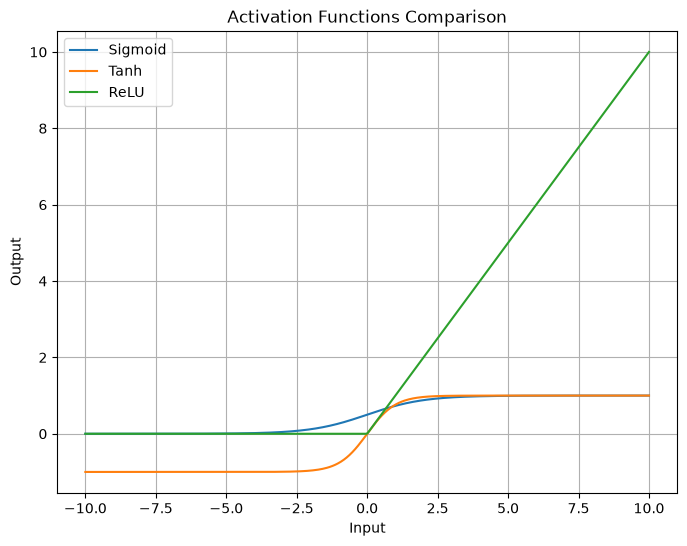

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# 입력 값 생성: -10부터 10까지 균일하게 분포된 400개의 값
x = np.linspace(-10, 10, 400)

# Sigmoid 함수
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Tanh 함수 (numpy 내장 함수 사용)
def tanh(x):
    return np.tanh(x)

# ReLU 함수
def relu(x):
    return np.maximum(0, x)

# 활성화 함수 계산
y_sigmoid = sigmoid(x)
y_tanh = tanh(x)
y_relu = relu(x)

# 그래프 시각화
plt.figure(figsize=(8, 6))
plt.plot(x, y_sigmoid, label='Sigmoid')
plt.plot(x, y_tanh, label='Tanh')
plt.plot(x, y_relu, label='ReLU')
plt.xlabel('Input')
plt.ylabel('Output')
plt.title('Activation Functions Comparison')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

In [11]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
data_iter = iter(train_loader)
images, labels = next(data_iter)
print(images.shape)  

torch.Size([64, 1, 28, 28])


In [12]:
class SimpleMLP(nn.Module):
    def __init__(self):
        super(SimpleMLP, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = x.view(-1, 28*28)
        return self.fc(x)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

model = SimpleMLP()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        optimizer.zero_grad()              
        outputs = model(images)            
        loss = criterion(outputs, labels)  
        loss.backward()                    
        optimizer.step()                   
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    print(epoch+1, avg_loss)

def evaluate(model, data_loader):
    model.eval()  
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in data_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    return accuracy

test_accuracy = evaluate(model, test_loader)
print(test_accuracy)

1 0.25328565816253995
2 0.10964544502787911
3 0.07718520737074411
4 0.06014859918450345
5 0.048012867690558465
97.31


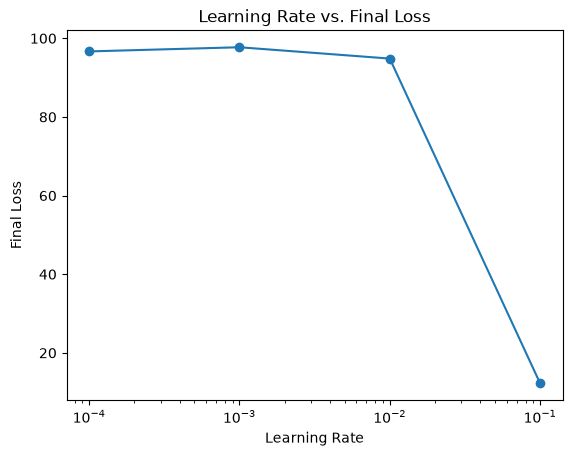

In [13]:
import matplotlib.pyplot as plt
import torch.optim as optim

learning_rates = [0.1, 0.01, 0.001, 0.0001]
final_accuracies = []

for lr in learning_rates:
    model = SimpleMLP()  
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    for epoch in range(10):
        model.train()
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
    
    accuracy = evaluate(model, test_loader)
    final_accuracies.append(accuracy)

plt.plot(learning_rates, final_accuracies, marker='o')
plt.xlabel("Learning Rate")  
plt.ylabel("Test Accuracy (%)")  
plt.title("Learning Rate vs. Test Accuracy")  
plt.xscale('log')
plt.show()

In [14]:
class MNISTNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.network = nn.Sequential(
            nn.Linear(28*28, 128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 64),    nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 10)
        )
    def forward(self, x):
        return self.network(self.flatten(x))

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
train = datasets.MNIST('./data', train=True, download=True, transform=transform)
test  = datasets.MNIST('./data', train=False, transform=transform)
train_loader = torch.utils.data.DataLoader(train, batch_size=64, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test,  batch_size=1000, shuffle=False)



In [15]:
model     = MNISTNet()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
train_losses = []
model.train()
for _ in range(5):
    running = 0.0
    for data, target in train_loader:
        out = model(data)
        loss = criterion(out, target)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        running += loss.item()
    train_losses.append(running / len(train_loader))



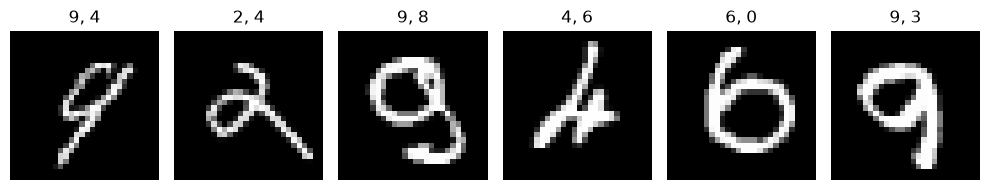

In [16]:
wrong_images, wrong_preds, wrong_targets = [], [], []
model.eval()
with torch.no_grad():
    for data, target in test_loader:
        out   = model(data)
        preds = out.argmax(dim=1)
        mask  = preds != target
        idxs  = mask.nonzero(as_tuple=True)[0]
        for i in idxs:
            if len(wrong_images) >= 6: break
            wrong_images.append(data[i])
            wrong_preds.append(preds[i].item())
            wrong_targets.append(target[i].item())

        if len(wrong_images) >= 6:
            break


plt.figure(figsize=(10,4))
for i in range(len(wrong_images)):
    ax = plt.subplot(1,6,i+1)
    ax.imshow(wrong_images[i].squeeze(), cmap='gray')
    ax.axis('off')
    ax.set_title(f'{wrong_targets[i]}, {wrong_preds[i]}')
plt.tight_layout()
plt.show()

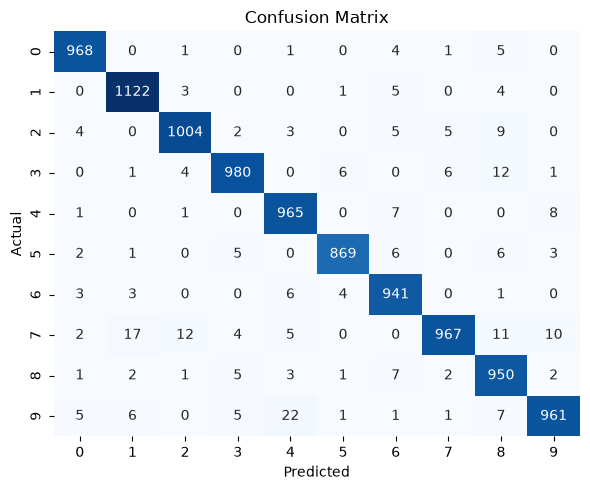

In [17]:
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for data, target in test_loader:
        out = model(data)
        all_preds.extend(out.argmax(dim=1).tolist())
        all_labels.extend(target.tolist())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

0.0
 0, 58.4, 78.41
 10, 98.3, 86.42
 20, 100.0, 88.63
 30, 100.0, 89.59
 40, 100.0, 89.62
과적합 점수: 10.4% (훈련-테스트 정확도 차이)
0.2
 0, 52.6, 77.05
 10, 99.4, 87.57
 20, 99.9, 89.78
 30, 99.7, 89.38
 40, 100.0, 90.57
과적합 점수: 10.5% (훈련-테스트 정확도 차이)
0.5
 0, 26.4, 58.11
 10, 94.7, 88.39
 20, 97.0, 89.28
 30, 98.3, 89.26
 40, 98.1, 88.84
과적합 점수: 9.6% (훈련-테스트 정확도 차이)
0.8
 0, 11.1, 27.07
 10, 38.0, 61.88
 20, 59.3, 77.32
 30, 70.8, 81.58
 40, 72.2, 83.97
과적합 점수: -9.7% (훈련-테스트 정확도 차이)


C:\Users\KDS-22\AppData\Local\Temp\ipykernel_23392\2476723541.py:152: UserWarning: Glyph 49552 (\N{HANGUL SYLLABLE SON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\KDS-22\AppData\Local\Temp\ipykernel_23392\2476723541.py:152: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\KDS-22\AppData\Local\Temp\ipykernel_23392\2476723541.py:152: UserWarning: Glyph 54632 (\N{HANGUL SYLLABLE HAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\KDS-22\AppData\Local\Temp\ipykernel_23392\2476723541.py:152: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\KDS-22\AppData\Local\Temp\ipykernel_23392\2476723541.py:152: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\KDS-22\AppData\Local\Temp\ipykernel_23392\2476723541.py:152: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}

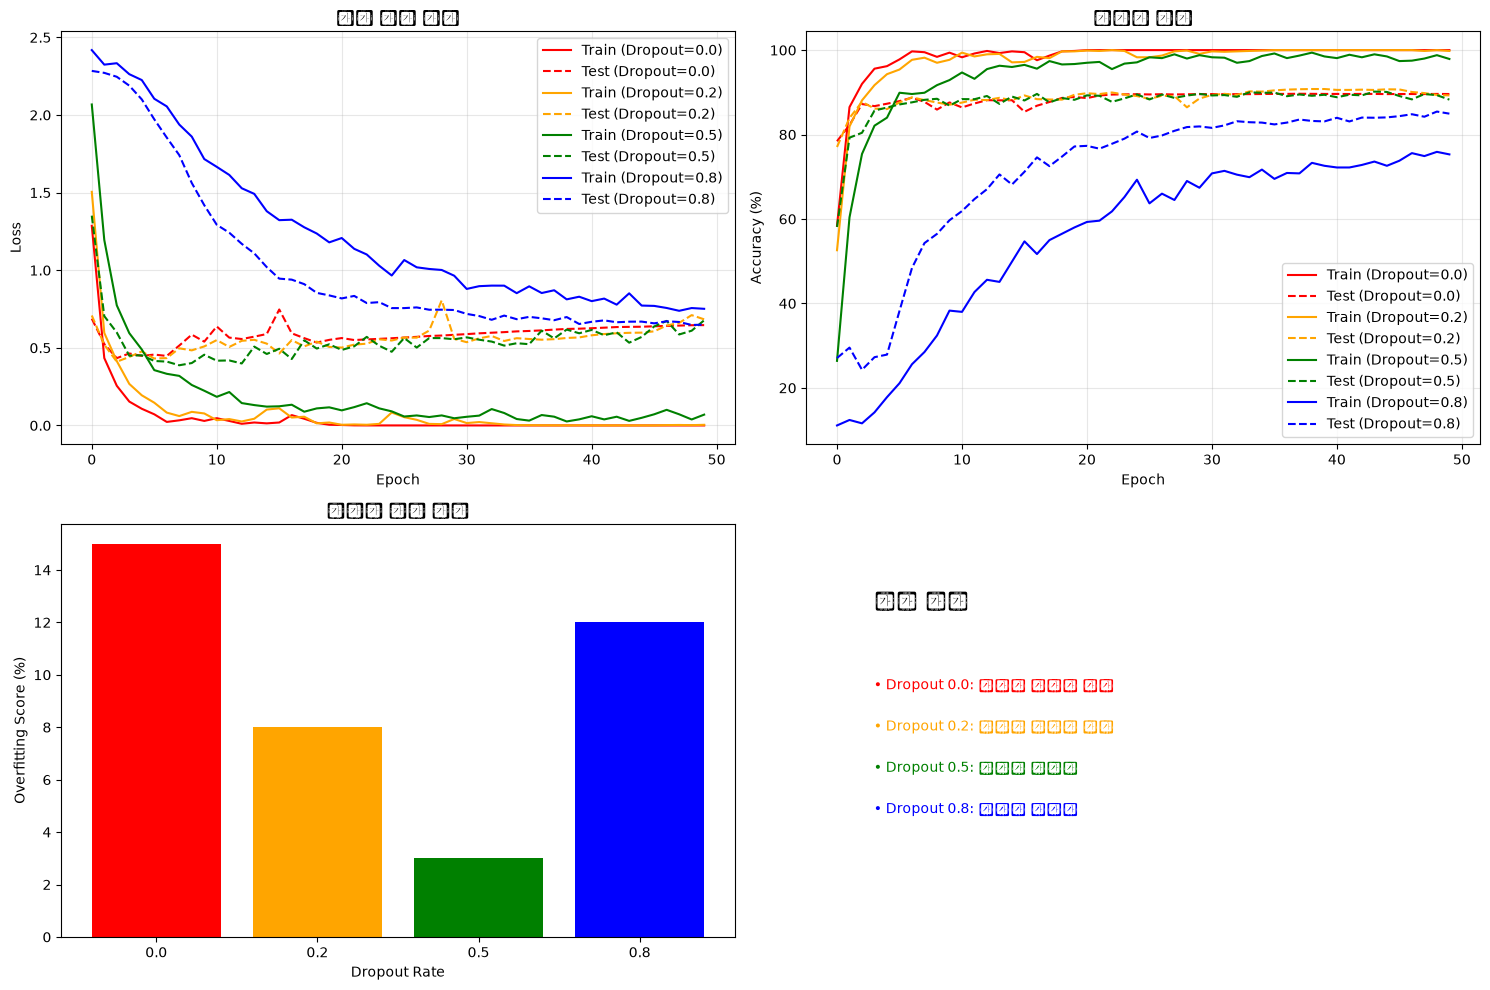


탐정 결론:
Dropout 0.5 근처가 최적의 균형점!
너무 낮으면 과적합, 너무 높으면 학습 부족!


In [19]:
def overfitting_detective():
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])

    train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
    test_dataset = datasets.MNIST('./data', train=False, transform=transform)

    train_subset = torch.utils.data.Subset(train_dataset, range(1000))  

    train_loader = torch.utils.data.DataLoader(train_subset, batch_size=32, shuffle=True)
    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1000, shuffle=False)


    class OverfittingNet(nn.Module):
        def __init__(self, dropout_rate):
            super().__init__()
            self.flatten = nn.Flatten()
            self.network = nn.Sequential(
                nn.Linear(784, 512),
                nn.ReLU(),
                nn.Dropout(dropout_rate),
                nn.Linear(512, 256),
                nn.ReLU(),
                nn.Dropout(dropout_rate),
                nn.Linear(256, 128),
                nn.ReLU(),
                nn.Dropout(dropout_rate),
                nn.Linear(128, 10)
            )

        def forward(self, x):
            return self.network(self.flatten(x))

    dropout_rates = [0.0, 0.2, 0.5, 0.8]
    colors = ['red', 'orange', 'green', 'blue']

    plt.figure(figsize=(15, 10))
    overfitting_scores = []

    for i, dropout_rate in enumerate(dropout_rates):
        print(dropout_rate)

        model = OverfittingNet(dropout_rate)
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        criterion = nn.CrossEntropyLoss()

        train_losses = []
        test_losses = []
        train_accuracies = []
        test_accuracies = []

        for epoch in range(50):  
            
            model.train()
            train_loss = 0
            train_correct = 0
            train_total = 0

            for data, target in train_loader:
                optimizer.zero_grad()
                output = model(data)
                loss = criterion(output, target)
                loss.backward()
                optimizer.step()

                train_loss += loss.item()
                _, predicted = torch.max(output.data, 1)
                train_total += target.size(0)
                train_correct += (predicted == target).sum().item()

            
            model.eval()
            test_loss = 0
            test_correct = 0
            test_total = 0

            with torch.no_grad():
                for data, target in test_loader:
                    output = model(data)
                    test_loss += criterion(output, target).item()
                    _, predicted = torch.max(output.data, 1)
                    test_total += target.size(0)
                    test_correct += (predicted == target).sum().item()

            
            train_losses.append(train_loss / len(train_loader))
            test_losses.append(test_loss / len(test_loader))
            train_accuracies.append(100 * train_correct / train_total)
            test_accuracies.append(100 * test_correct / test_total)

            if epoch % 10 == 0:
                print(f" {epoch}, {train_accuracies[-1]}, {test_accuracies[-1]}")

        
        # 그래프 그리기
        plt.subplot(2, 2, 1)
        plt.plot(train_losses, color=colors[i], linestyle='-', label=f'Train (Dropout={dropout_rate})')
        plt.plot(test_losses, color=colors[i], linestyle='--', label=f'Test (Dropout={dropout_rate})')

        plt.subplot(2, 2, 2)
        plt.plot(train_accuracies, color=colors[i], linestyle='-', label=f'Train (Dropout={dropout_rate})')
        plt.plot(test_accuracies, color=colors[i], linestyle='--', label=f'Test (Dropout={dropout_rate})')

        # 과적합 정도 계산
        overfitting_score = train_accuracies[-1] - test_accuracies[-1]
        overfitting_scores.append(overfitting_score)
        print(f"과적합 점수: {overfitting_score:.1f}% (훈련-테스트 정확도 차이)")

    # 그래프 꾸미기
    plt.subplot(2, 2, 1)
    plt.title('손실 함수 변화')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 2, 2)
    plt.title('정확도 변화')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # 과적합 분석
    plt.subplot(2, 2, 3)
    plt.bar(range(len(dropout_rates)), overfitting_scores, color=colors)
    plt.title('과적합 정도 비교')
    plt.xlabel('Dropout Rate')
    plt.ylabel('Overfitting Score (%)')
    plt.xticks(range(len(dropout_rates)), dropout_rates)

    # 탐정 결론
    plt.subplot(2, 2, 4)
    plt.text(0.1, 0.8, '탐정 결론', fontsize=14, weight='bold')
    best_idx = int(np.argmin(np.abs(overfitting_scores)))
    conclusions = [
        f'• Dropout {rate}: 과적합 점수 {score:.1f}%'
        for rate, score in zip(dropout_rates, overfitting_scores)
    ]

    for i, conclusion in enumerate(conclusions):
        plt.text(0.1, 0.6-i*0.1, conclusion, fontsize=10, color=colors[i])

    plt.axis('off')
    plt.tight_layout()
    plt.show()

    print("\n탐정 결론:")
    print(f"훈련-테스트 정확도 차이가 가장 작은 Dropout: {dropout_rates[best_idx]}")

# 실행
overfitting_detective()